<a href="https://colab.research.google.com/github/Lord-LLM/Zero-Shot-Job-Resume-to-Description-Matcher/blob/main/Zero_Shot_Job_Resume_to_Description_Matcher.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kagglehub

In [3]:
import kagglehub

In [4]:
kagglehub.login()

In [5]:
from kagglehub import KaggleDatasetAdapter

In [6]:
df_resume = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "snehaanbhawal/resume-dataset",
    "Resume/Resume.csv",
)

100%|██████████| 7.97M/7.97M [00:01<00:00, 5.10MB/s]

Extracting zip of Resume.csv...


In [7]:
df_resume.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [8]:
!pip install datasets

In [9]:
from datasets import load_dataset

dataset = load_dataset("azrai99/job-dataset", split="train")

README.md:   0%|          | 0.00/5.20k [00:00<?, ?B/s]

jobstreet_all_job_dataset.csv: reconstructing file:   0%|          |  0.00B /  123MB            

jobstreet_all_job_dataset.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/59306 [00:00<?, ? examples/s]

In [10]:
import pandas as pd
pd.set_option('display.max_columns', None)

df_jobPostings = pd.DataFrame(dataset)

print(f"Dataset Shape: {df_jobPostings.shape} (Rows, Columns)")
df_jobPostings.head()

Dataset Shape: (59306, 11) (Rows, Columns)


,job_id,job_title,company,descriptions,location,category,subcategory,role,type,salary,listingDate
0,74630583,Procurement Executive (Contract),Coca-Cola Bottlers (Malaysia) Sdn Bhd,Position Purpose\nManage aspects of procuremen...,Negeri Sembilan,"Manufacturing, Transport & Logistics","Purchasing, Procurement & Inventory",procurement-executive,Contract/Temp,None,2024-03-21T05:58:35Z
1,74660602,Account Executive/ Assistant,Acoustic & Lighting System Sdn Bhd,We are looking for a Account Executive/ Assist...,Petaling,Accounting,Bookkeeping & Small Practice Accounting,executive-assistant,Full time,"RM 2,800 – RM 3,200 per month",2024-03-22T06:52:57Z
2,74655679,"Data Analyst - Asset Management, SPX Express",Shopee Mobile Malaysia Sdn Bhd,Performs detailed data analysis on existing sp...,Klang District,"Manufacturing, Transport & Logistics",Analysis & Reporting,asset-management-analyst,Full time,None,2024-03-22T04:22:43Z
3,74657624,Service Engineer,Sun Medical Systems Sdn Bhd,"You are important for troubleshooting, install...",Petaling,Engineering,Electrical/Electronic Engineering,services-engineer,Full time,"RM 3,000 – RM 3,500 per month",2024-03-22T05:32:09Z
4,74679363,Purchasing Executive,Magnet Security & Automation Sdn. Bhd.,"MAG is a trailblazer in the industry, boasting...",Hulu Langat,"Manufacturing, Transport & Logistics","Purchasing, Procurement & Inventory",purchasing-executive,Full time,"RM 2,800 – RM 3,500 per month",2024-03-23T03:56:39Z


In [11]:
df_resume.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [12]:
df_resume.describe()

,ID
count,2.484000e+03
mean,3.182616e+07
std,2.145735e+07
min,3.547447e+06
25%,1.754430e+07
50%,2.521031e+07
75%,3.611444e+07
max,9.980612e+07


In [13]:
df_jobPostings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59306 entries, 0 to 59305
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   job_id        59306 non-null  int64 
 1   job_title     59306 non-null  object
 2   company       59306 non-null  object
 3   descriptions  59306 non-null  object
 4   location      59306 non-null  object
 5   category      59306 non-null  object
 6   subcategory   59306 non-null  object
 7   role          57370 non-null  object
 8   type          59306 non-null  object
 9   salary        26641 non-null  object
 10  listingDate   59306 non-null  object
dtypes: int64(1), object(10)
memory usage: 5.0+ MB


In [14]:
df_jobPostings.describe()

,job_id
count,5.930600e+04
mean,7.497790e+07
std,9.319422e+05
min,7.134223e+07
25%,7.433293e+07
50%,7.478895e+07
75%,7.572671e+07
max,7.669411e+07


In [15]:
import re
def clean_text(text: str) -> str:
    """
    Minimal cleaning: normalize whitespace, strip stray page-number/OCR
    artifacts. Deliberately NOT lowercasing, stemming, or removing
    punctuation — sentence-transformer models are trained on natural
    sentences and are robust to case/punctuation; over-cleaning throws
    away information the model actually uses.
    """
    if not isinstance(text, str):
        return ""

    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"page\s*\d+\s*(of\s*\d+)?", "", text, flags=re.IGNORECASE)

    # Strip leading/trailing whitespace
    return text.strip()



# Regex-based section splitter

SECTION_HEADERS = [
    "summary", "objective", "skills", "technical skills", "core competencies",
    "experience", "work experience", "professional experience", "employment history",
    "education", "certifications", "projects", "achievements",
]

_headers_sorted = sorted(SECTION_HEADERS, key=len, reverse=True)
_header_pattern = re.compile(
    r"(?<![A-Za-z])(" + "|".join(re.escape(h) for h in _headers_sorted) + r")(?![A-Za-z])",
    flags=re.IGNORECASE,
)


def split_sections(text: str) -> dict:
    """
    Find every header occurrence in `text` and slice the text between
    consecutive headers. Returns a dict of {header_name: section_text}.
    """
    matches = list(_header_pattern.finditer(text))
    sections = {}

    for i, match in enumerate(matches):
        header = match.group(1).lower()
        start = match.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        section_text = text[start:end].strip(" :\u2022-\t")
        if section_text:
            # If the same header appears twice, append rather than overwrite
            sections[header] = (sections.get(header, "") + " " + section_text).strip()

    return sections


def get_skills_experience_summary(text: str) -> str:
    """
    Convenience wrapper for pulling out just the skills + experience sections and concatenates them into one string,
    ready to embed. Falls back to the full cleaned text if no headers were
    found (some resumes won't match any keyword — don't silently produce
    an empty string).
    """
    sections = split_sections(text)

    wanted = [
        sections.get("skills", ""),
        sections.get("technical skills", ""),
        sections.get("core competencies", ""),
        sections.get("experience", ""),
        sections.get("work experience", ""),
        sections.get("professional experience", ""),
        sections.get("employment history", ""),
    ]
    combined = " ".join(w for w in wanted if w).strip()

    return combined if combined else text



if __name__ == "__main__":

     df_resume["clean_text"] = df_resume["Resume_str"].apply(clean_text)
     df_resume["embed_input_naive"] = df_resume["clean_text"]

     df_resume["embed_input_structured"] = df_resume["clean_text"].apply(get_skills_experience_summary)

     for i in range(3):
         print(df_resume.loc[i, "Category"])
         print(split_sections(df_resume.loc[i, "clean_text"]).keys())

HR
dict_keys(['summary', 'experience', 'skills', 'education'])
HR
dict_keys(['summary', 'experience', 'education', 'skills'])
HR
dict_keys(['summary', 'experience', 'skills', 'education'])


In [16]:
from sentence_transformers import SentenceTransformer

In [17]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### Clean Job Postings and Generate Embeddings

In [18]:
df_jobPostings["clean_text"] = df_jobPostings["descriptions"].apply(clean_text)
df_jobPostings["embed_input_structured"] = df_jobPostings["clean_text"].apply(get_skills_experience_summary)

# Display some examples of the processed job descriptions
print("Original Job Description (first 3):\n", df_jobPostings['descriptions'].head(3).tolist())
print("\nCleaned Job Description (first 3):\n", df_jobPostings['clean_text'].head(3).tolist())
print("\nStructured Input for Embedding (first 3):\n", df_jobPostings['embed_input_structured'].head(3).tolist())

Original Job Description (first 3):
 ['Position Purpose\nManage aspects of procurement including supplier management, contract management, and vendor performance tracking. Support the administration and management of procurement processes. This includes setting up, maintaining, and administering purchasing databases; developing and issuing purchase orders; maintain contract log and providing support to other departments within the organization who are involved in procurement.\nKey Duties / Responsibilities\nGeneral\nEnsure the PO created following the bidding requirements\nOA updates from time to time - upon request from planning team / buyers\nGeographical coverage: Malaysia and Singapore operations\nEnsure all purchasing activities comply with Procurement Procedure and company internal policy\nActively seek out opportunities for improvement, ways to do things better; and lead implementation of actions defined\nManage reports and reviews\nManage reports and reviews weekly, monthly and

In [19]:
resume_embeddings = model.encode(df_resume["embed_input_structured"].tolist(), convert_to_tensor=True, device='cuda')
job_embeddings = model.encode(df_jobPostings["embed_input_structured"].tolist(), convert_to_tensor=True, device='cuda')

print(f"Shape of Resume Embeddings: {resume_embeddings.shape}")
print(f"Shape of Job Postings Embeddings: {job_embeddings.shape}")

Shape of Resume Embeddings: torch.Size([2484, 384])
Shape of Job Postings Embeddings: torch.Size([59306, 384])


### Compute Similarity Matrix

In [20]:
from sentence_transformers.util import cos_sim

similarity_matrix = cos_sim(resume_embeddings, job_embeddings)

print(f"Shape of Similarity Matrix: {similarity_matrix.shape}")
print("First 5x5 entries of the Similarity Matrix:\n", similarity_matrix[:5, :5])

Shape of Similarity Matrix: torch.Size([2484, 59306])
First 5x5 entries of the Similarity Matrix:
 tensor([[0.2440, 0.3890, 0.3454, 0.2340, 0.1475],
        [0.2729, 0.3797, 0.4605, 0.2824, 0.3066],
        [0.2789, 0.2645, 0.2822, 0.2224, 0.0692],
        [0.2233, 0.2645, 0.3688, 0.2017, 0.1474],
        [0.2493, 0.3114, 0.3708, 0.2221, 0.1660]], device='cuda:0')


### Visualize Similarity Matrix with Heatmap

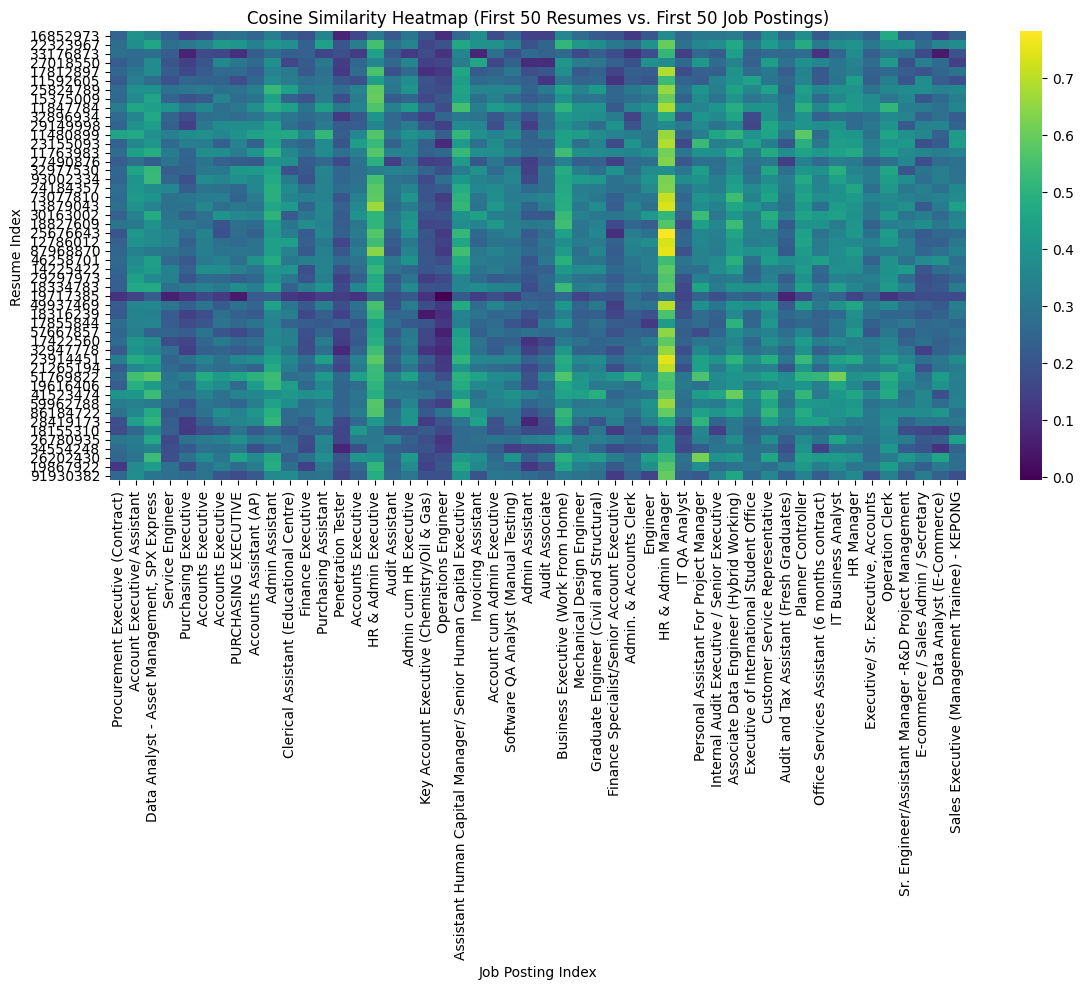

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

subset_similarity_matrix = similarity_matrix[:50, :50].cpu().numpy()

plt.figure(figsize=(12, 10))
sns.heatmap(
    subset_similarity_matrix,
    annot=False,
    cmap='viridis',
    fmt=".2f",
    xticklabels=df_jobPostings['job_title'].head(50).tolist(),
    yticklabels=df_resume['ID'].head(50).tolist()
)
plt.title('Cosine Similarity Heatmap (First 50 Resumes vs. First 50 Job Postings)')
plt.xlabel('Job Posting Index')
plt.ylabel('Resume Index')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
def category_match_rate(sim_matrix, df_resume, df_jobs, k=5):

    hits = 0
    for i in range(len(df_resume)):
        resume_cat = str(df_resume["Category"].iloc[i]).lower()
        top_idxs = top_k_jobs(sim_matrix, i, k=k)
        job_cats = df_jobs["category"].iloc[top_idxs].astype(str).str.lower()
        if job_cats.str.contains(resume_cat, na=False).any() or any(
            resume_cat in jc or jc in resume_cat for jc in job_cats
        ):
            hits += 1
    return hits / len(df_resume)


def inspect_examples(sim_matrix, df_resume, df_jobs, n=3, k=5):
    """Print a handful of resumes and their top-k matched job titles for a manual read."""
    for i in range(n):
        print(f"\nResume category: {df_resume['Category'].iloc[i]}")
        top_idxs = top_k_jobs(sim_matrix, i, k=k)
        for rank, idx in enumerate(top_idxs, 1):
            score = sim_matrix[i, idx]
            print(f"  {rank}. [{score:.3f}] {df_jobs['job_title'].iloc[idx]}"
                  f" (category: {df_jobs['category'].iloc[idx]})")


if __name__ == "__main__":
    # Quantitative ablation comparison
    rate_naive = category_match_rate(sim_naive, df_resume, df_jobs, k=5)
    rate_structured = category_match_rate(sim_structured, df_resume, df_jobs, k=5)
    print(f"Naive (whole-resume) top-5 category match rate:      {rate_naive:.2%}")
    print(f"Structured (skills+exp) top-5 category match rate:   {rate_structured:.2%}")

    # Sanity-check the raw score distribution — flags the "collapse" failure mode
    print(f"\nNaive similarity — mean: {sim_naive.mean():.3f}, std: {sim_naive.std():.3f}")
    print(f"Structured similarity — mean: {sim_structured.mean():.3f}, std: {sim_structured.std():.3f}")

    # Qualitative read
    print("\n--- Naive embedding examples ---")
    inspect_examples(sim_naive, df_resume, df_jobs)
    print("\n--- Structured embedding examples ---")
    inspect_examples(sim_structured, df_resume, df_jobs)

    # Heatmaps for both variants, side by side conceptually
    plot_heatmap(sim_naive, df_resume, df_jobs, title="Naive whole-resume embedding")
    plot_heatmap(sim_structured, df_resume, df_jobs, title="Structured skills+experience embedding")